# D.1 Modelljämförelse — GLM M2 vs XGBoost

Slutjämförelse av båda modellerna:

1. **Validering 2024** — samma out-of-sample-punkt som i B1, nu med GLM och XGBoost sida vid sida
2. **Test 2025** — låst testset, används en gång här

**Principer:** Båda modellerna har identiskt feature-set (`Verksamhet`, `GeografisktOmrade`, `log(Omsättning)`) och identisk exponering (`log(Duration)` som offset i GLM, `base_margin` i XGBoost). `Ar` utesluts — kategoriskt Ar kan inte prediktera 2024/2025 i GLM.

**Beslutsregel:** Föredra XGBoost endast om förbättringen är materiell. Annars behålls GLM M2 för tolkningsbarheten.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
from sklearn.metrics import mean_poisson_deviance

SEED = 42
np.random.seed(SEED)

print(f"xgboost:     {xgb.__version__}")
print(f"sklearn:     {sklearn.__version__}")
print(f"statsmodels: {sm.__version__}")

xgboost:     3.2.0
sklearn:     1.8.0
statsmodels: 0.14.6


In [2]:
data_dir = Path("../../../data")
df_tr_full = pd.read_csv(data_dir / "Entreprenadförsäkring training.csv")
df_test = pd.read_csv(data_dir / "Entreprenadförsäkring test.csv")

for name, d in (("Träning", df_tr_full), ("Test", df_test)):
    assert (d["Duration"] > 0).all(), f"Duration ≤ 0 i {name}"
    assert d.isna().sum().sum() == 0, f"Saknade värden i {name}"

for d in (df_tr_full, df_test):
    d["Ar"] = d["Ar"].astype(int)
    d["log_duration"] = np.log(d["Duration"])
    d["log_omsattning"] = np.log(d["Omsattning"])

df_train = df_tr_full[df_tr_full["Ar"].isin([2021, 2022, 2023])].copy()
df_val = df_tr_full[df_tr_full["Ar"] == 2024].copy()

# Lås kategorinivåer på hela träningsdatan (2021-2024) → används även på 2025
CAT_COLS = ["Verksamhet", "GeografisktOmrade"]
for col in CAT_COLS:
    dtype = pd.CategoricalDtype(categories=sorted(df_tr_full[col].unique()))
    for d in (df_train, df_val, df_tr_full, df_test):
        assert set(d[col].unique()) <= set(dtype.categories), f"Okänd nivå i {col}"
        d[col] = d[col].astype(dtype)

print(f"Träning 2021-2023: {len(df_train):,} rader ({int(df_train['AntalSkador'].sum()):,} skador)")
print(f"Validering 2024:   {len(df_val):,} rader ({int(df_val['AntalSkador'].sum()):,} skador)")
print(f"Träning 2021-2024: {len(df_tr_full):,} rader ({int(df_tr_full['AntalSkador'].sum()):,} skador)")
print(f"Test 2025:         {len(df_test):,} rader ({int(df_test['AntalSkador'].sum()):,} skador)")

Träning 2021-2023: 755,691 rader (14,284 skador)
Validering 2024:   277,695 rader (5,446 skador)
Träning 2021-2024: 1,033,386 rader (19,730 skador)
Test 2025:         291,649 rader (5,520 skador)


In [3]:
FEATURES = ["Verksamhet", "GeografisktOmrade", "log_omsattning"]
GLM_FORMULA = (
    "AntalSkador ~ C(Verksamhet, Treatment(reference='Byggföretag')) "
    "+ C(GeografisktOmrade, Treatment(reference='Landsbyggd')) "
    "+ log_omsattning"
)


def total_poisson_deviance(y_true, y_pred):
    """Total Poisson-deviance (jämförbar med statsmodels GLM.deviance)."""
    y_pred = np.clip(y_pred, 1e-12, None)
    return mean_poisson_deviance(y_true, y_pred) * len(y_true)


def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "Poisson deviance": total_poisson_deviance(y_true, y_pred),
        "RMSE": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "MAE": float(np.mean(np.abs(y_true - y_pred))),
        "Totalt observerat": float(y_true.sum()),
        "Totalt predikterat": float(y_pred.sum()),
        "Portföljfel %": float(100 * (y_pred.sum() - y_true.sum()) / y_true.sum()),
    }


def predict_xgb(booster, X, duration, num_iter):
    """Predikt med log(Duration) som exponering → count-space."""
    dmat = xgb.DMatrix(X, base_margin=np.log(duration), enable_categorical=True)
    return booster.predict(dmat, iteration_range=(0, num_iter))

## Del 1 — Validering 2024

Båda modellerna tränas på 2021–2023 och utvärderas på 2024.

In [4]:
m2 = smf.glm(
    GLM_FORMULA, data=df_train,
    family=sm.families.Poisson(), offset=df_train["log_duration"],
).fit()
glm_val_pred = m2.predict(df_val, offset=df_val["log_duration"]).values
glm_val_m = metrics(df_val["AntalSkador"].values, glm_val_pred)

print(f"GLM M2 AIC (2021-2023): {m2.aic:,.2f}")
print(f"GLM M2 valideringsdeviance (2024): {glm_val_m['Poisson deviance']:,.1f}")

GLM M2 AIC (2021-2023): 136,971.03
GLM M2 valideringsdeviance (2024): 41,002.4


In [5]:
best_config = json.load(open("./artifacts/C-best-config.json"))
print(f"Vald config: {best_config['valt_namn']}")
print(f"num_boost_round: {best_config['num_boost_round']}")

X_train = df_train[FEATURES]
y_train = df_train["AntalSkador"].values
X_val = df_val[FEATURES]
y_val = df_val["AntalSkador"].values

dtrain = xgb.DMatrix(
    X_train, label=y_train,
    base_margin=np.log(df_train["Duration"].values),
    enable_categorical=True,
)
dval = xgb.DMatrix(
    X_val, label=y_val,
    base_margin=np.log(df_val["Duration"].values),
    enable_categorical=True,
)

xgb_val = xgb.train(
    best_config["hyperparams"], dtrain,
    num_boost_round=best_config["num_boost_round"],
    evals=[(dval, "val")], verbose_eval=False,
)
xgb_val_pred = predict_xgb(xgb_val, X_val, df_val["Duration"].values, best_config["num_boost_round"])
xgb_val_m = metrics(y_val, xgb_val_pred)

print(f"XGBoost valideringsdeviance (2024): {xgb_val_m['Poisson deviance']:,.1f}")

Vald config: shallow-fast
num_boost_round: 232


XGBoost valideringsdeviance (2024): 40,918.1


In [6]:
val_tbl = pd.DataFrame({"GLM M2": glm_val_m, "XGBoost": xgb_val_m})
val_tbl["Δ (XGB − GLM)"] = val_tbl["XGBoost"] - val_tbl["GLM M2"]
val_tbl["Relativt (%)"] = 100 * val_tbl["Δ (XGB − GLM)"] / val_tbl["GLM M2"]
display(val_tbl.style.format("{:,.4f}"))

,GLM M2,XGBoost,Δ (XGB − GLM),Relativt (%)
Poisson deviance,"41,002.3957","40,918.1077",-84.2880,-0.2056
RMSE,0.1406,0.1406,-0.0000,-0.0228
MAE,0.0375,0.0375,0.0000,0.0205
Totalt observerat,"5,446.0000","5,446.0000",0.0000,0.0000
Totalt predikterat,"5,250.3363","5,252.8237",2.4874,0.0474
Portföljfel %,-3.5928,-3.5471,0.0457,-1.2713


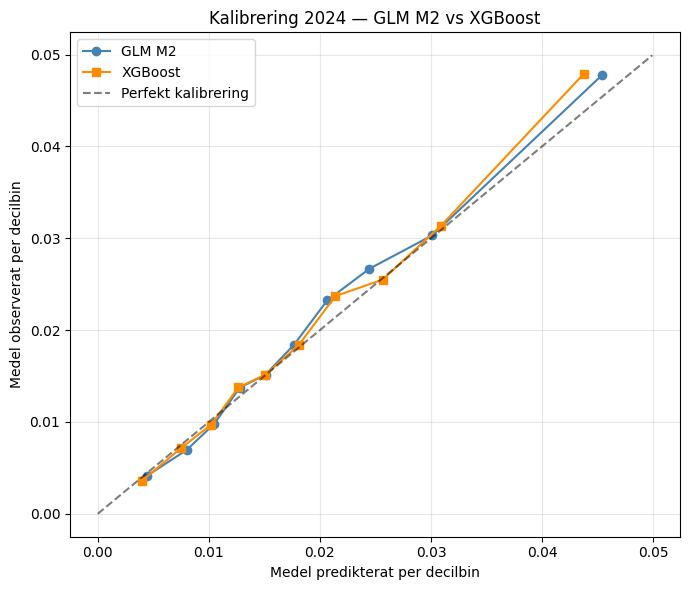

In [7]:
def calibration_bins(y_true, y_pred, n_bins=10):
    order = np.argsort(y_pred)
    yt, yp = y_true[order], y_pred[order]
    size = len(yt) // n_bins
    rows = []
    for i in range(n_bins):
        lo = i * size
        hi = len(yt) if i == n_bins - 1 else (i + 1) * size
        rows.append({"mean_pred": yp[lo:hi].mean(), "mean_obs": yt[lo:hi].mean()})
    return pd.DataFrame(rows)

cal_glm = calibration_bins(y_val, glm_val_pred)
cal_xgb = calibration_bins(y_val, xgb_val_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(cal_glm["mean_pred"], cal_glm["mean_obs"], "o-", label="GLM M2", color="steelblue")
ax.plot(cal_xgb["mean_pred"], cal_xgb["mean_obs"], "s-", label="XGBoost", color="darkorange")
lims = [0, max(cal_glm["mean_pred"].max(), cal_xgb["mean_pred"].max()) * 1.1]
ax.plot(lims, lims, "k--", alpha=0.5, label="Perfekt kalibrering")
ax.set_xlabel("Medel predikterat per decilbin")
ax.set_ylabel("Medel observerat per decilbin")
ax.set_title("Kalibrering 2024 — GLM M2 vs XGBoost")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Del 2 — Slutligt test på 2025

Båda modellerna tränas om på hela 2021–2024-datan med låsta specifikationer. Ingen ny tuning.

In [8]:
m2_full = smf.glm(
    GLM_FORMULA, data=df_tr_full,
    family=sm.families.Poisson(), offset=df_tr_full["log_duration"],
).fit()
glm_test_pred = m2_full.predict(df_test, offset=df_test["log_duration"]).values
print(f"GLM M2 (full 2021-2024) AIC: {m2_full.aic:,.2f}")

GLM M2 (full 2021-2024) AIC: 188,728.90


In [9]:
X_full = df_tr_full[FEATURES]
y_full = df_tr_full["AntalSkador"].values
dfull = xgb.DMatrix(
    X_full, label=y_full,
    base_margin=np.log(df_tr_full["Duration"].values),
    enable_categorical=True,
)
xgb_full = xgb.train(
    best_config["hyperparams"], dfull,
    num_boost_round=best_config["num_boost_round"],
    verbose_eval=False,
)

train_pred = predict_xgb(xgb_full, X_full, df_tr_full["Duration"].values, best_config["num_boost_round"])
assert (train_pred >= 0).all()
assert abs(train_pred.sum() - y_full.sum()) / y_full.sum() < 0.05

xgb_test_pred = predict_xgb(xgb_full, df_test[FEATURES], df_test["Duration"].values, best_config["num_boost_round"])
assert (xgb_test_pred >= 0).all()

y_test = df_test["AntalSkador"].values
glm_test_m = metrics(y_test, glm_test_pred)
xgb_test_m = metrics(y_test, xgb_test_pred)

test_tbl = pd.DataFrame({"GLM M2": glm_test_m, "XGBoost": xgb_test_m})
test_tbl["Δ (XGB − GLM)"] = test_tbl["XGBoost"] - test_tbl["GLM M2"]
test_tbl["Relativt (%)"] = 100 * test_tbl["Δ (XGB − GLM)"] / test_tbl["GLM M2"]
display(test_tbl.style.format("{:,.4f}"))

,GLM M2,XGBoost,Δ (XGB − GLM),Relativt (%)
Poisson deviance,"41,889.1711","41,855.7434",-33.4277,-0.0798
RMSE,0.1374,0.1374,-0.0000,-0.0154
MAE,0.0371,0.0371,0.0000,0.0601
Totalt observerat,"5,520.0000","5,520.0000",0.0000,0.0000
Totalt predikterat,"5,580.6272","5,587.3091",6.6819,0.1197
Portföljfel %,1.0983,1.2194,0.1210,11.0213


## Segmentnivå-jämförelse (2025)

Brytning per `Verksamhet`, per `GeografisktOmrade`, per `Omsättning`-decil.

In [10]:
def segment_breakdown(df, y_true, glm_pred, xgb_pred, group_col):
    d = df.copy()
    d["_y"], d["_glm"], d["_xgb"] = y_true, glm_pred, xgb_pred
    rows = []
    for g, sub in d.groupby(group_col, observed=True):
        rows.append({
            group_col: g, "n": len(sub),
            "Observerat": sub["_y"].sum(),
            "GLM pred": sub["_glm"].sum(),
            "XGB pred": sub["_xgb"].sum(),
            "GLM dev": total_poisson_deviance(sub["_y"].values, sub["_glm"].values),
            "XGB dev": total_poisson_deviance(sub["_y"].values, sub["_xgb"].values),
        })
    res = pd.DataFrame(rows)
    res["GLM fel %"] = 100 * (res["GLM pred"] - res["Observerat"]) / res["Observerat"]
    res["XGB fel %"] = 100 * (res["XGB pred"] - res["Observerat"]) / res["Observerat"]
    return res

FMT = {"Observerat": "{:,.0f}", "GLM pred": "{:,.1f}", "XGB pred": "{:,.1f}",
       "GLM dev": "{:,.1f}", "XGB dev": "{:,.1f}",
       "GLM fel %": "{:+.1f}", "XGB fel %": "{:+.1f}"}

display(segment_breakdown(df_test, y_test, glm_test_pred, xgb_test_pred, "Verksamhet").style.format(FMT))

,Verksamhet,n,Observerat,GLM pred,XGB pred,GLM dev,XGB dev,GLM fel %,XGB fel %
0,Byggföretag,116594,"2,286","2,305.8","2,306.9","17,364.8","17,355.7",+0.9,+0.9
1,Elektriker,28923,411,400.0,404.0,"3,354.5","3,352.3",-2.7,-1.7
2,Grävning & Schaktning,23410,372,396.5,398.2,"2,980.7","2,976.5",+6.6,+7.1
3,Målare,29172,332,368.7,376.1,"2,884.2","2,888.4",+11.1,+13.3
4,Takarbeten,14545,353,328.3,328.0,"2,510.4","2,512.3",-7.0,-7.1
5,VVS,29100,858,823.9,815.2,"5,831.8","5,820.1",-4.0,-5.0
6,Övriga specialistföretag,49905,908,957.3,959.0,"6,962.6","6,950.4",+5.4,+5.6


In [11]:
display(segment_breakdown(df_test, y_test, glm_test_pred, xgb_test_pred, "GeografisktOmrade").style.format(FMT))

,GeografisktOmrade,n,Observerat,GLM pred,XGB pred,GLM dev,XGB dev,GLM fel %,XGB fel %
0,Landsbyggd,29093,470,462.7,462.9,"3,746.7","3,737.4",-1.5,-1.5
1,Mellanstorstad,87602,"1,603","1,688.0","1,689.8","12,237.5","12,242.7",+5.3,+5.4
2,Småstad,58280,701,703.7,712.9,"6,006.6","6,000.7",+0.4,+1.7
3,Storstad,116674,"2,746","2,726.1","2,721.8","19,898.3","19,874.9",-0.7,-0.9


In [12]:
df_test_d = df_test.copy()
df_test_d["OmsDecil"] = pd.qcut(df_test_d["Omsattning"], 10, labels=[f"D{i+1}" for i in range(10)])
display(segment_breakdown(df_test_d, y_test, glm_test_pred, xgb_test_pred, "OmsDecil").style.format(FMT))

,OmsDecil,n,Observerat,GLM pred,XGB pred,GLM dev,XGB dev,GLM fel %,XGB fel %
0,D1,29177,193,236.4,194.3,"1,913.3","1,908.9",+22.5,+0.7
1,D2,29177,289,319.6,283.4,"2,624.6","2,626.8",+10.6,-1.9
2,D3,29149,338,375.8,363.6,"2,946.6","2,950.4",+11.2,+7.6
3,D4,29158,451,425.9,438.5,"3,681.0","3,682.0",-5.6,-2.8
4,D5,29181,505,480.2,537.2,"4,020.9","4,021.1",-4.9,+6.4
5,D6,29155,583,536.6,584.7,"4,474.1","4,472.5",-8.0,+0.3
6,D7,29164,566,601.2,591.7,"4,379.1","4,378.9",+6.2,+4.5
7,D8,29158,669,682.9,691.4,"4,929.8","4,929.7",+2.1,+3.4
8,D9,29166,851,804.3,859.5,"5,944.2","5,945.1",-5.5,+1.0
9,D10,29164,"1,075","1,117.7","1,043.0","6,975.5","6,940.5",+4.0,-3.0


## Modellval

Rekommendationen bygger på två jämförelsepunkter:

1. **Valideringsdeviance på 2024** — primär out-of-sample-metrik
2. **Portföljfel och deviance på 2025-testet** — slutlig utvärdering

**Beslutsregel:** Föredra XGBoost endast om förbättringen är materiell (>2 % lägre deviance + jämförbart portföljfel). Annars behålls GLM M2 för tolkningsbarheten (rate ratios + konfidensintervall = direkt affärslogik).

In [13]:
val_dev_delta = 100 * (xgb_val_m["Poisson deviance"] - glm_val_m["Poisson deviance"]) / glm_val_m["Poisson deviance"]
test_dev_delta = 100 * (xgb_test_m["Poisson deviance"] - glm_test_m["Poisson deviance"]) / glm_test_m["Poisson deviance"]

print(f"Val deviance 2024   GLM: {glm_val_m['Poisson deviance']:,.1f}   XGB: {xgb_val_m['Poisson deviance']:,.1f}   Δ: {val_dev_delta:+.2f}%")
print(f"Test deviance 2025  GLM: {glm_test_m['Poisson deviance']:,.1f}   XGB: {xgb_test_m['Poisson deviance']:,.1f}   Δ: {test_dev_delta:+.2f}%")
print(f"Portföljfel 2025    GLM: {glm_test_m['Portföljfel %']:+.2f}%   XGB: {xgb_test_m['Portföljfel %']:+.2f}%")

print("\nRekommendation:")
if val_dev_delta < -2.0 and abs(xgb_test_m["Portföljfel %"]) <= abs(glm_test_m["Portföljfel %"]) + 0.5:
    print("  → XGBoost ger materiell förbättring — rekommendera som komplementär prediktionsmotor.")
elif val_dev_delta < 0 and test_dev_delta < 0:
    print("  → XGBoost marginellt bättre. För liten förbättring för komplexitetsökningen.")
    print("    Behåll GLM M2 som huvudmodell. XGBoost rapporteras som sanity check.")
else:
    print("  → GLM M2 likvärdig/bättre. Behåll GLM M2 som huvudmodell.")

Val deviance 2024   GLM: 41,002.4   XGB: 40,918.1   Δ: -0.21%
Test deviance 2025  GLM: 41,889.2   XGB: 41,855.7   Δ: -0.08%
Portföljfel 2025    GLM: +1.10%   XGB: +1.22%

Rekommendation:
  → XGBoost marginellt bättre. För liten förbättring för komplexitetsökningen.
    Behåll GLM M2 som huvudmodell. XGBoost rapporteras som sanity check.
